In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import firwin, lfilter

In [2]:
def leer_eeg_bitalino(path):
    fs = 1000
    columna = 5
    resolution = 10

    with open(path, 'r') as f:
        lines = f.readlines()

    fin_header_idx = next(i for i, line in enumerate(lines) if "EndOfHeader" in line)
    df = pd.read_csv(path, sep='\t', skiprows=fin_header_idx + 1, header=None)
    raw_eeg = df.iloc[:, columna].values

    eeg_microvolts = ((((raw_eeg / (2 ** resolution)) - 0.5) * 3.3) / 40000) * 1e6
    t = np.arange(len(eeg_microvolts)) / fs

    return eeg_microvolts, t

In [4]:
def fir_bandpass_filter(data, fs, fc, numtaps=101):
    nyq = fs / 2
    fir_coeff = firwin(numtaps, fc / nyq, window='hann')
    return lfilter(fir_coeff, 1.0, data)

In [12]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, data)
    return filtered

### 1. Filtrado IIR y FIR de Señal EEG con parpadeos

In [20]:
parpadeo1, t1 = leer_eeg_bitalino('../Laboratorio 5 - Adquisicion de EEG/EEG Raw/parpadeo1.txt')
parpadeo1_iir = butter_bandpass_filter(parpadeo1, 0.5, 30, 1000,4)
parpadeo1_fir = fir_bandpass_filter(parpadeo1, fs=1000, fc=12)

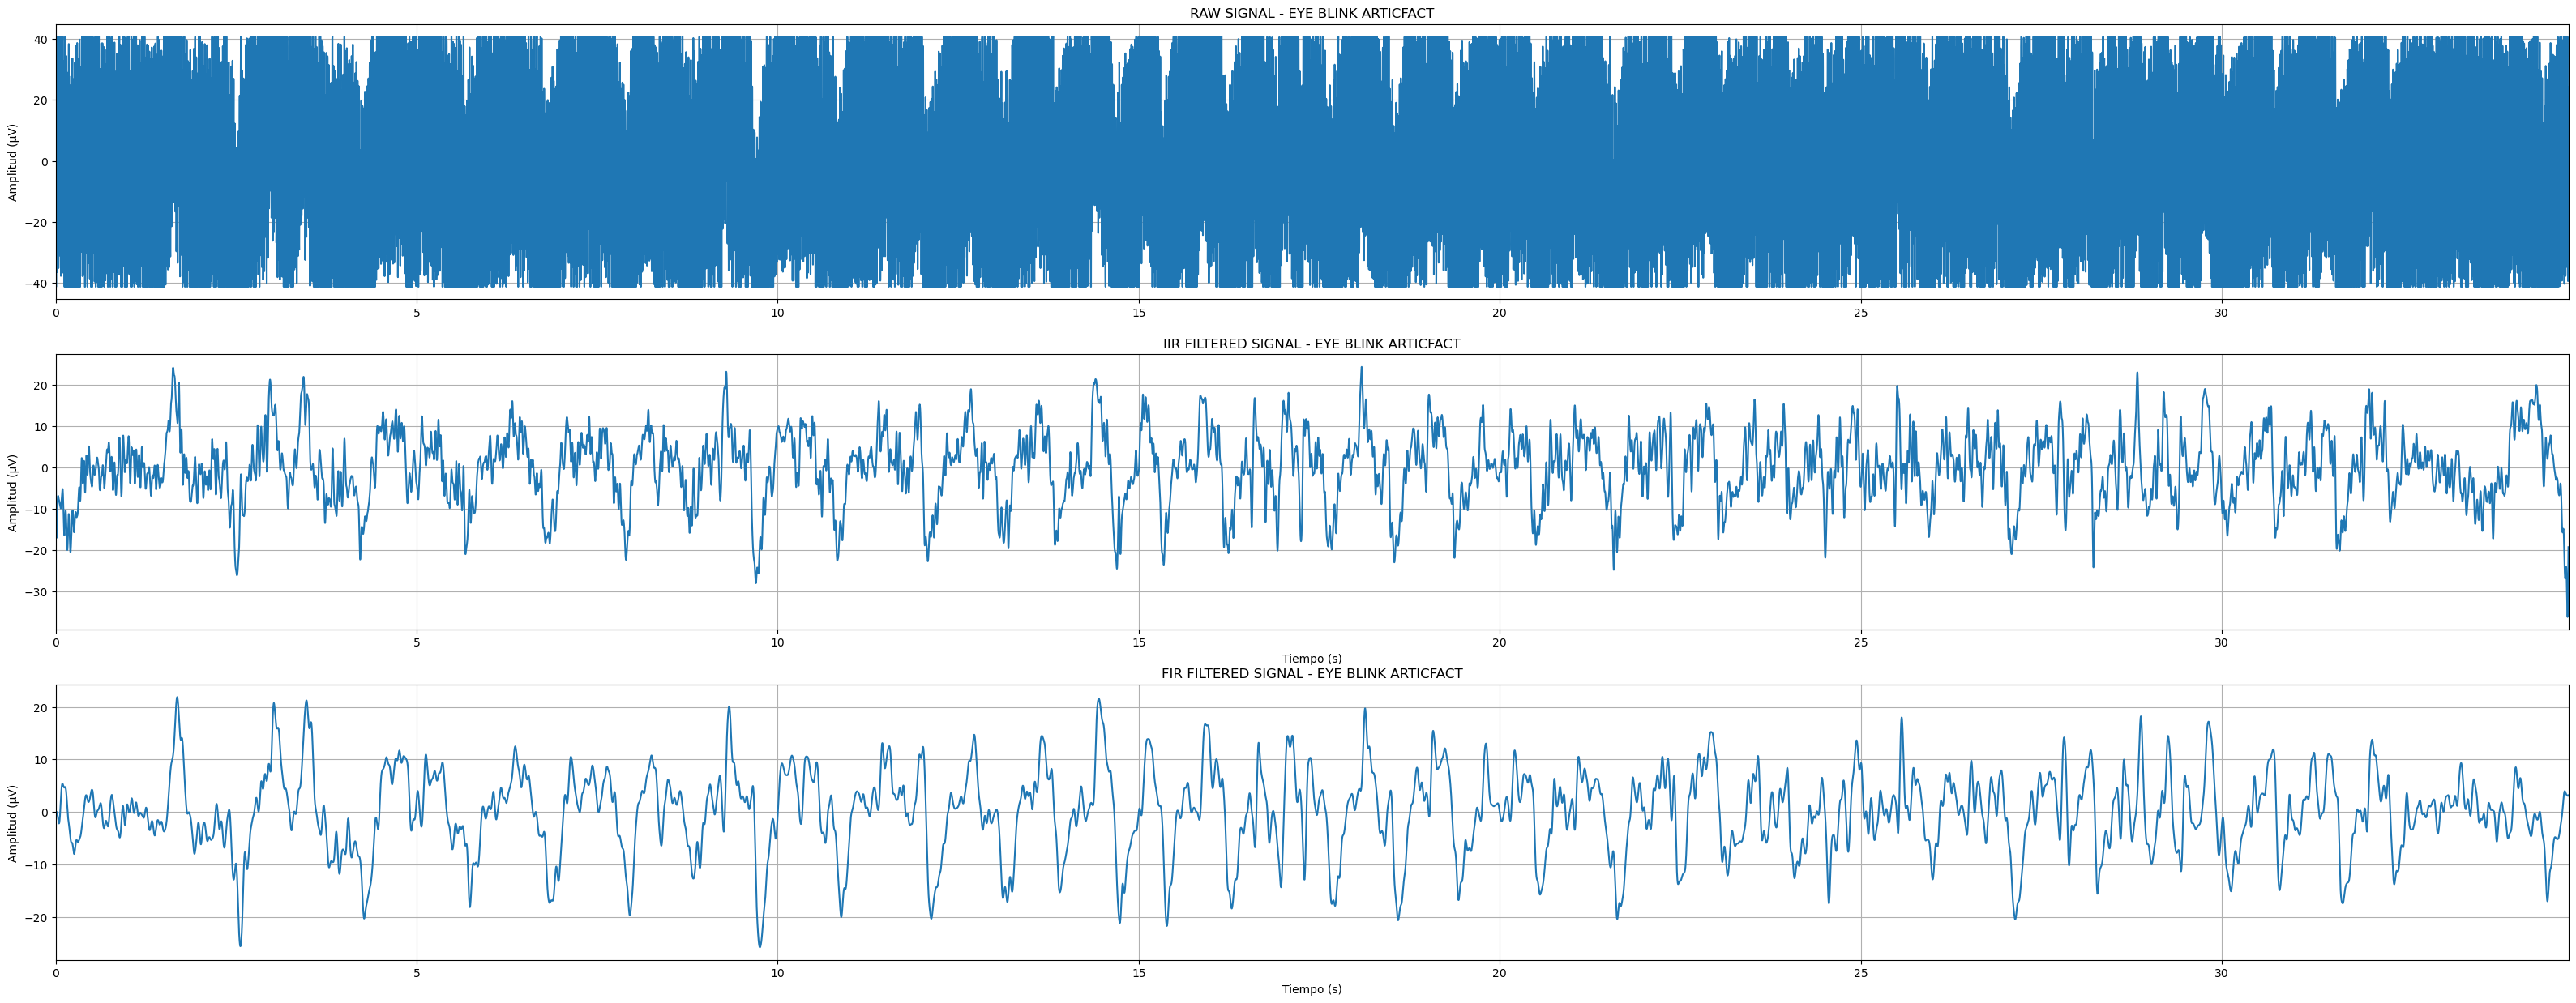

In [35]:
plt.figure(figsize=(40,15))

plt.subplot(3,1,1);plt.plot(t1, parpadeo1)
plt.xlim(0, t1[-1]);plt.ylabel("Amplitud (µV)");plt.grid(True);plt.title("RAW SIGNAL - EYE BLINK ARTICFACT")

plt.subplot(3,1,2);plt.plot(t1, parpadeo1_iir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("IIR FILTERED SIGNAL - EYE BLINK ARTICFACT")

plt.subplot(3,1,3);plt.plot(t1, parpadeo1_fir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FIR FILTERED SIGNAL - EYE BLINK ARTICFACT")

plt.show()

### 2. Filtrado IIR y FIR de Señal EEG mirando a un punto fijo

In [45]:
puntofijo, t2 = leer_eeg_bitalino('../Laboratorio 5 - Adquisicion de EEG/EEG Raw/puntofijo.txt')
puntofijo_iir = butter_bandpass_filter(puntofijo, 0.5, 30, 1000,4)
puntofijo_fir = fir_bandpass_filter(puntofijo, fs=1000, fc=12)

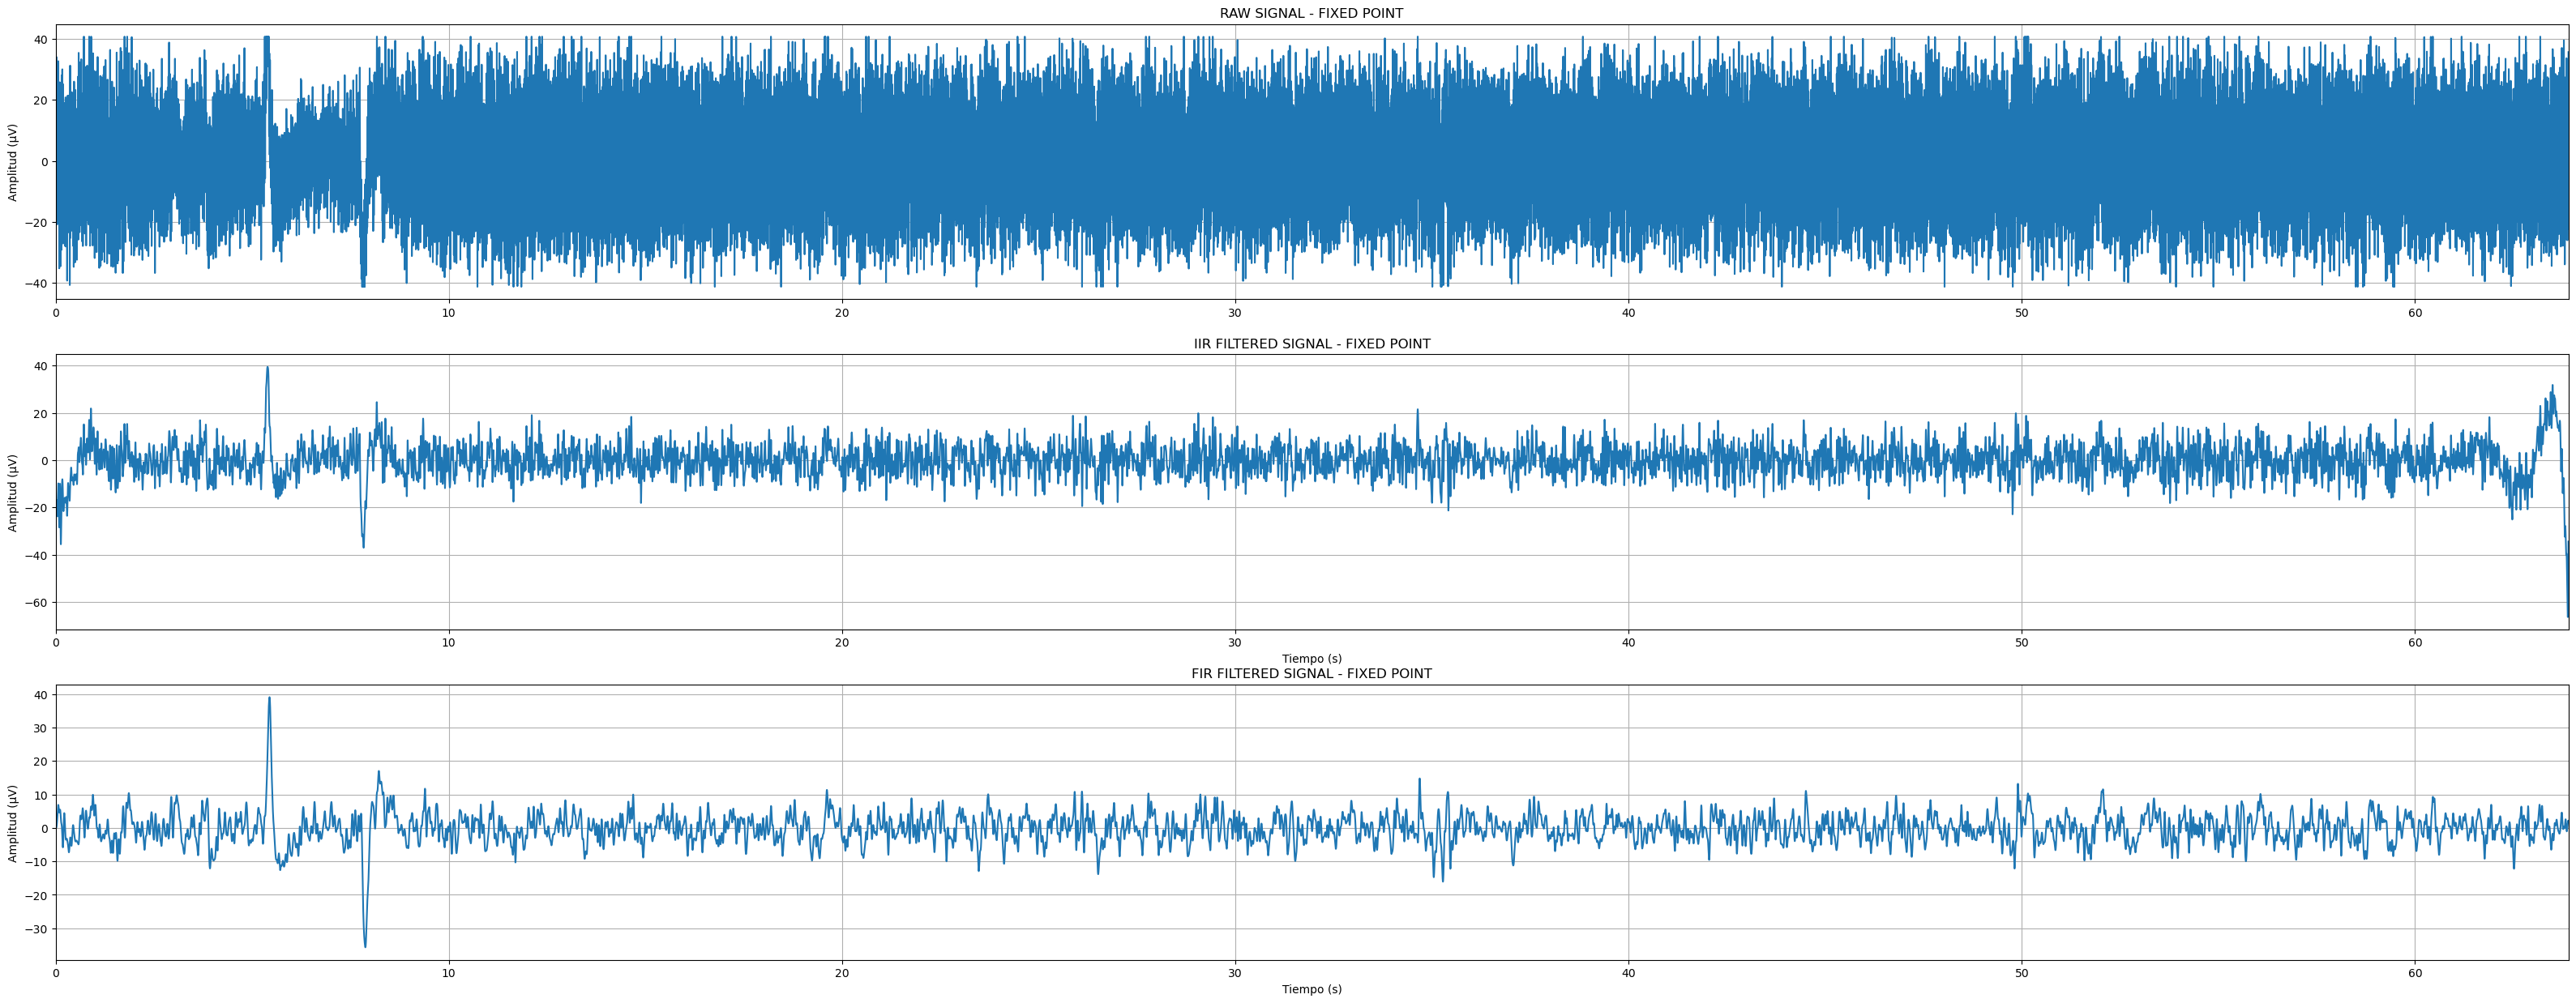

In [46]:
plt.figure(figsize=(40,15))

plt.subplot(3,1,1);plt.plot(t2, puntofijo)
plt.xlim(0, t1[-1]);plt.ylabel("Amplitud (µV)");plt.grid(True);plt.title("RAW SIGNAL - FIXED POINT")

plt.subplot(3,1,2);plt.plot(t2, puntofijo_iir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("IIR FILTERED SIGNAL - FIXED POINT")

plt.subplot(3,1,3);plt.plot(t2, puntofijo_fir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FIR FILTERED SIGNAL - FIXED POINT")

plt.show()

### 2. Filtrado IIR y FIR de Señal EEG haciendo tareas cognitivas

In [47]:
cognitive, t3 = leer_eeg_bitalino('../Laboratorio 5 - Adquisicion de EEG/EEG Raw/cognitivos.txt')
cognitive_iir = butter_bandpass_filter(cognitive, 0.5, 30, 1000,4)
cognitive_fir = fir_bandpass_filter(cognitive, fs=1000, fc=12)

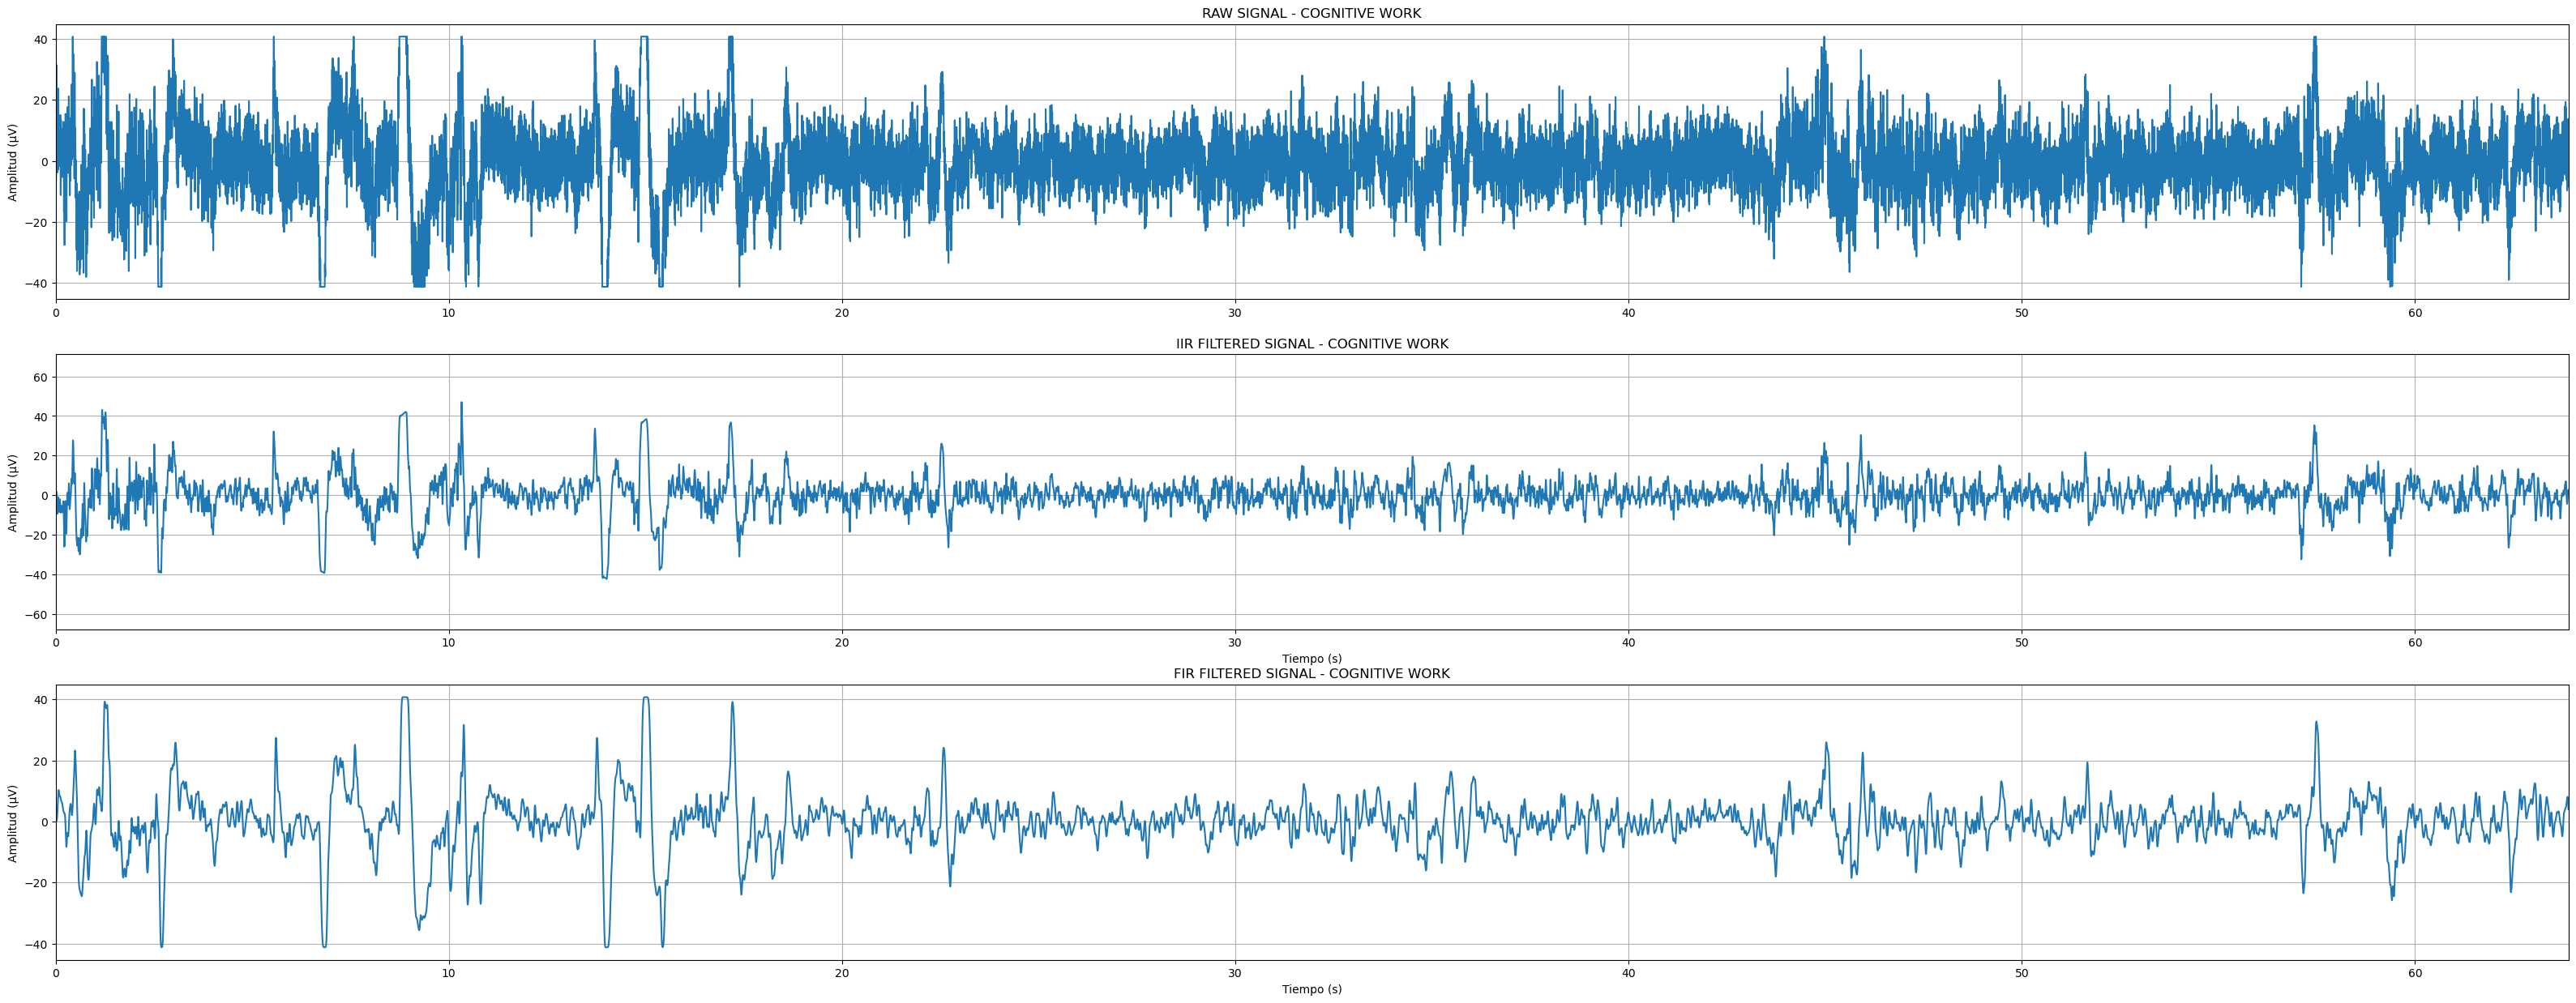

In [50]:
plt.figure(figsize=(40,15))

plt.subplot(3,1,1);plt.plot(t3, cognitive)
plt.xlim(0, t1[-1]);plt.ylabel("Amplitud (µV)");plt.grid(True);plt.title("RAW SIGNAL - COGNITIVE WORK")

plt.subplot(3,1,2);plt.plot(t3, cognitive_iir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("IIR FILTERED SIGNAL - COGNITIVE WORK")

plt.subplot(3,1,3);plt.plot(t3, cognitive_fir)
plt.xlim(0,t1[-1]);plt.ylabel("Amplitud (µV)");plt.xlabel("Tiempo (s)");plt.grid(True);plt.title("FIR FILTERED SIGNAL - COGNITIVE WORK")

plt.show()